Import Libraries and load dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
df = pd.read_csv("/content/drive/MyDrive/dev/sample-superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Data cleaning and aggregate sales by date

In [ ]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')

# Sort by date
df = df.sort_values('Order Date')

# Keep only needed columns
df = df[['Order Date', 'Sales']]

# Remove missing values
df = df.dropna()
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
df.head()

,Order Date,Sales
7980,2014-01-03,16.448
739,2014-01-04,11.784
740,2014-01-04,272.736
741,2014-01-04,3.540
1759,2014-01-05,19.536


Feature Engineering

In [ ]:
daily_sales['Year'] = daily_sales['Order Date'].dt.year
daily_sales['Month'] = daily_sales['Order Date'].dt.month
daily_sales['Day'] = daily_sales['Order Date'].dt.day

# Create target shift (next day sales prediction)
daily_sales['Target'] = daily_sales['Sales'].shift(-1)

daily_sales = daily_sales.dropna()
df

,Order Date,Sales
7980,2014-01-03,16.448
739,2014-01-04,11.784
740,2014-01-04,272.736
741,2014-01-04,3.540
1759,2014-01-05,19.536
...,...,...
645,2017-12-30,209.300
5091,2017-12-30,3.024
908,2017-12-30,52.776
907,2017-12-30,90.930


Train model

In [ ]:
features = ['Sales', 'Year', 'Month', 'Day']
X = daily_sales[features]
y = daily_sales['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Predictions

In [ ]:
y_pred = model.predict(X_test)

Evaluation

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1772.7545205390675
RMSE: 2395.5595438673827


Visualization

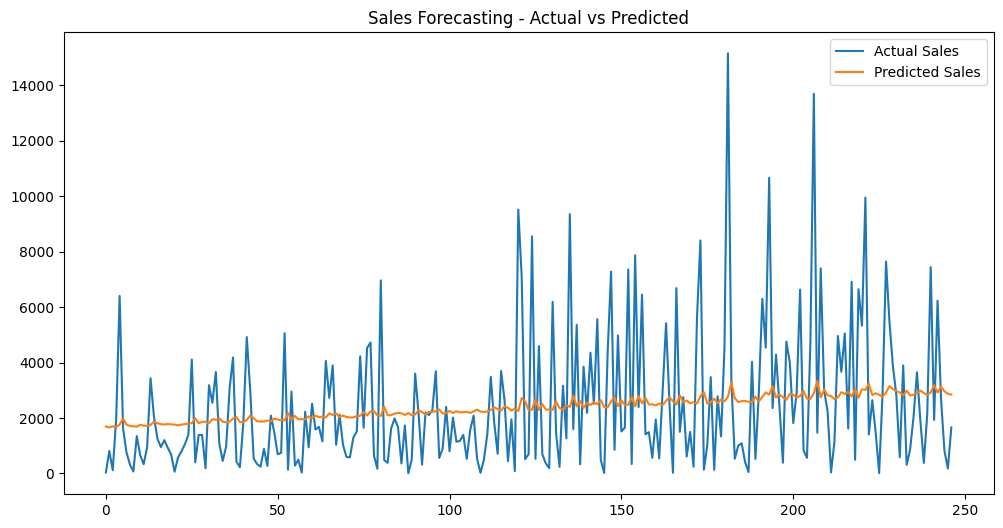

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual Sales")
plt.plot(y_pred, label="Predicted Sales")
plt.title("Sales Forecasting - Actual vs Predicted")
plt.legend()
plt.show()

Future Forecast

In [ ]:
last_row = daily_sales.iloc[-1].copy()

future_predictions = []

for i in range(7):
    input_data = pd.DataFrame([[
        last_row['Sales'],
        last_row['Year'],
        last_row['Month'],
        last_row['Day']
    ]], columns=features)

    pred = model.predict(input_data)[0]
    future_predictions.append(pred)

    # update for next iteration
    last_row['Sales'] = pred

Ploting future forecast

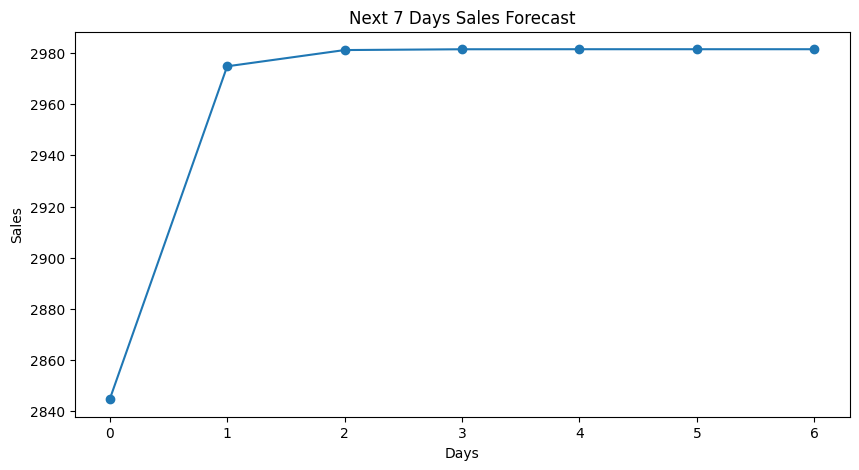

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(future_predictions, marker='o')
plt.title("Next 7 Days Sales Forecast")
plt.xlabel("Days")
plt.ylabel("Sales")
plt.show()